##Visual 1: Initial Data Scatter Plot
##Non-linear quartic relationship
##Heteroscedastic noise (increases with x)
##Why linear models fail here


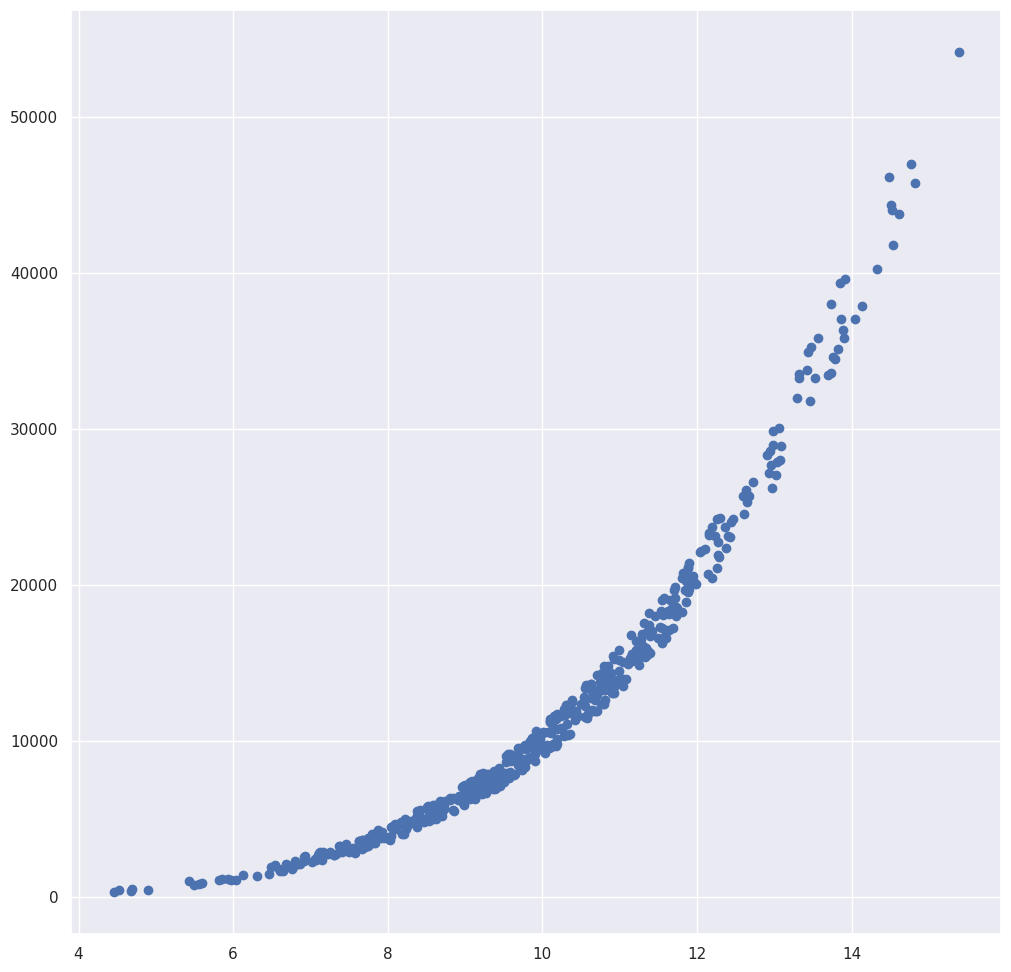

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(color_codes=True)
plt.rcParams["figure.figsize"] = [12,12]

#plt.figure(figsize=(12,12))


np.random.seed(0)
#DataSet_Given by :  y = f(x)  avec f(x) = x^4 + bx^3 + c

x = np.random.normal(10, 2, 500)
y = x ** 4 + np.random.uniform(-1, 1,500)*(x ** 3) + np.random.uniform(0, 1,500)

plt.scatter(x,y)
plt.show()

##Visual 2: Four Polynomial Fits (Degree 4, 16, 32, 64)
##Degree 4 - UNDERFITTING (smooth but bad fit)
##Degree 16 - OPTIMAL (smooth & accurate)
##Degree 32 - EARLY OVERFITTING (visible wiggles)
##Degree 64 - SEVERE OVERFITTING (erratic, interpolation)


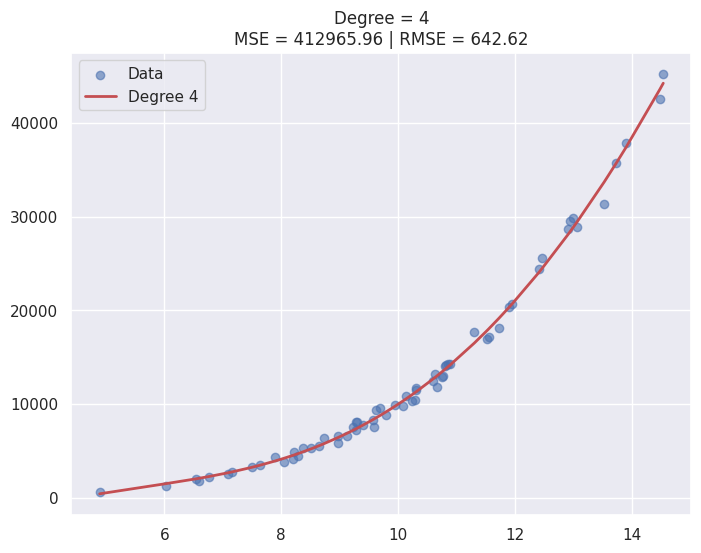

Degree: 4
MSE: 412965.9551971947
RMSE: 642.624272181805



/tmp/ipykernel_276/1437959961.py:14: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, degree)


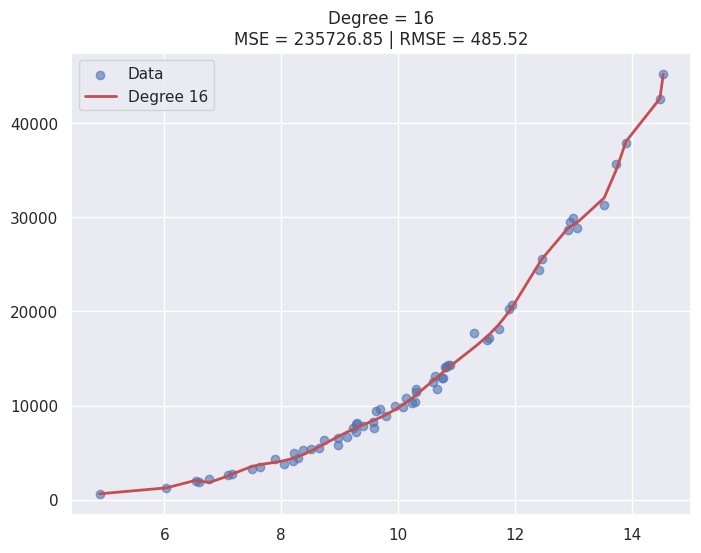

Degree: 16
MSE: 235726.8509750062
RMSE: 485.5170964806556



/tmp/ipykernel_276/1437959961.py:14: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, degree)


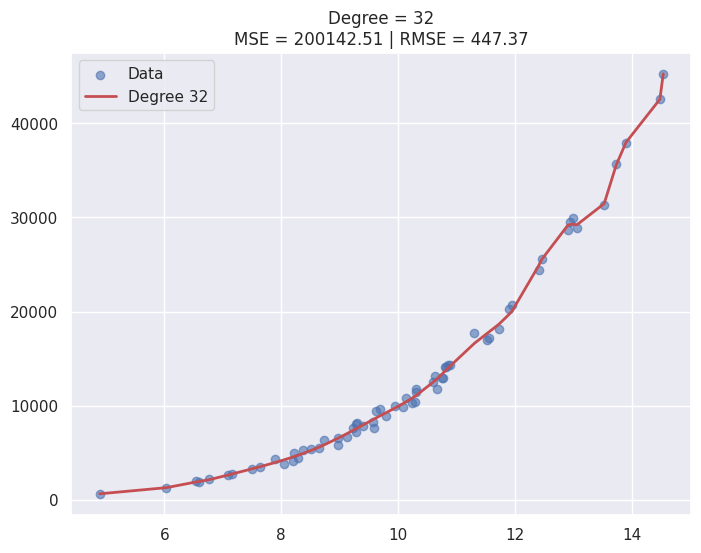

Degree: 32
MSE: 200142.5130889559
RMSE: 447.37290160329997



/tmp/ipykernel_276/1437959961.py:14: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, degree)


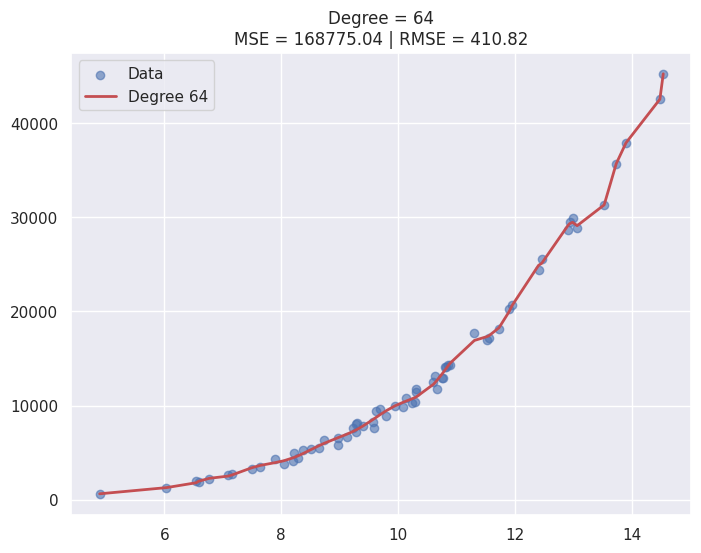

Degree: 64
MSE: 168775.04300000335
RMSE: 410.822398366987



In [25]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Fixed dataset
n = 64
x = np.random.normal(10, 2, n)
y = x**4 + np.random.uniform(-1, 1, n)*(x**3) + np.random.uniform(0, 1, n)

degrees = [4, 16, 32, 64]

def fit_and_plot(degree):
    coeffs = np.polyfit(x, y, degree)
    poly = np.poly1d(coeffs)

    y_pred = poly(x)

    mse = np.mean((y - y_pred)**2)
    rmse = np.sqrt(mse)

    # Smooth curve
    x_sorted = np.sort(x)
    y_sorted_pred = poly(x_sorted)

    plt.figure(figsize=(8,6))
    plt.scatter(x, y, alpha=0.6, label="Data")
    plt.plot(x_sorted, y_sorted_pred, 'r', linewidth=2, label=f"Degree {degree}")

    plt.title(f"Degree = {degree}\nMSE = {mse:.2f} | RMSE = {rmse:.2f}")
    plt.legend()
    plt.show()

    print(f"Degree: {degree}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}\n")

# Run for each degree
for d in degrees:
    fit_and_plot(d)

##Visual 3: MSE vs Degree (4 Points)
##Steep decline (bias-dominated region)
##Moderate decline (balanced region)
##Near-zero plateau (overfitting region)
##What's missing: test/validation error


/tmp/ipykernel_276/1708308830.py:12: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, d)
/tmp/ipykernel_276/1708308830.py:12: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, d)
/tmp/ipykernel_276/1708308830.py:12: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, d)


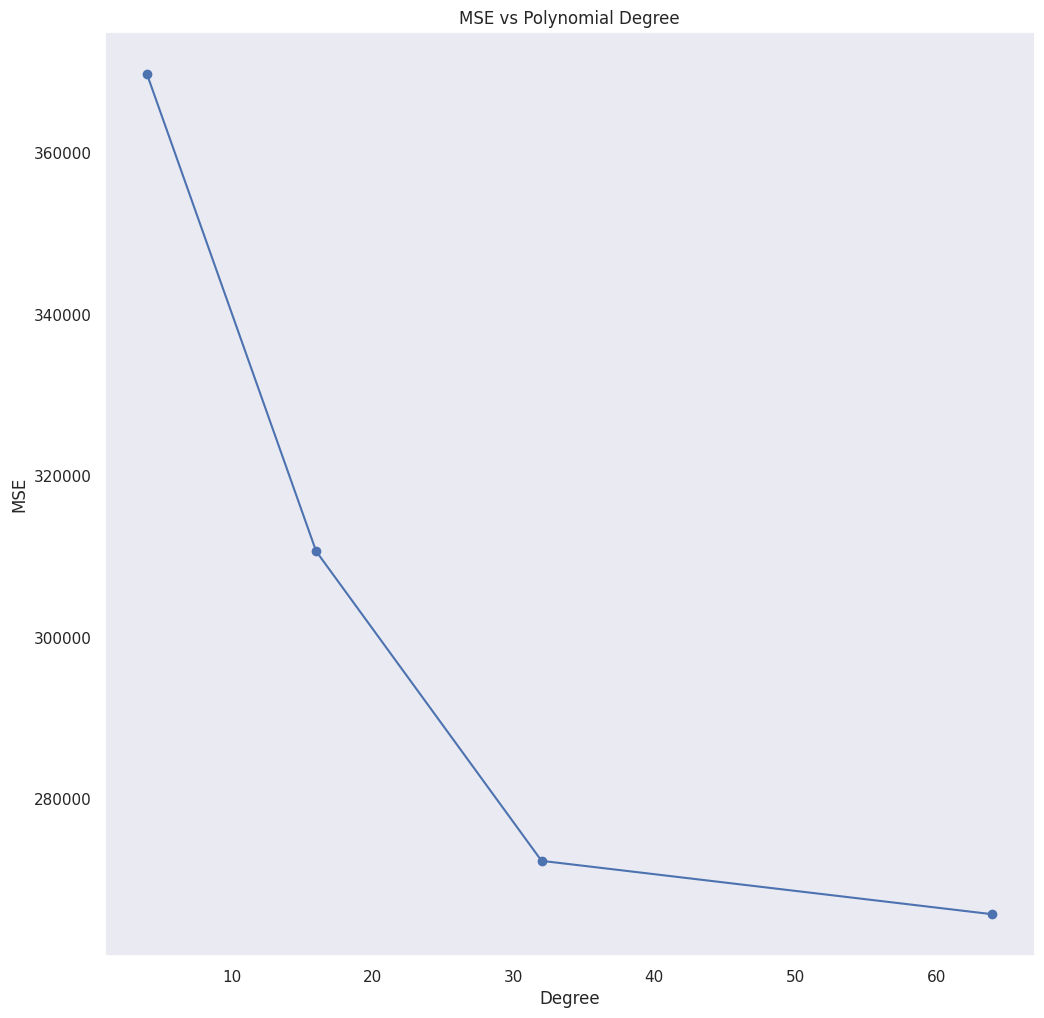

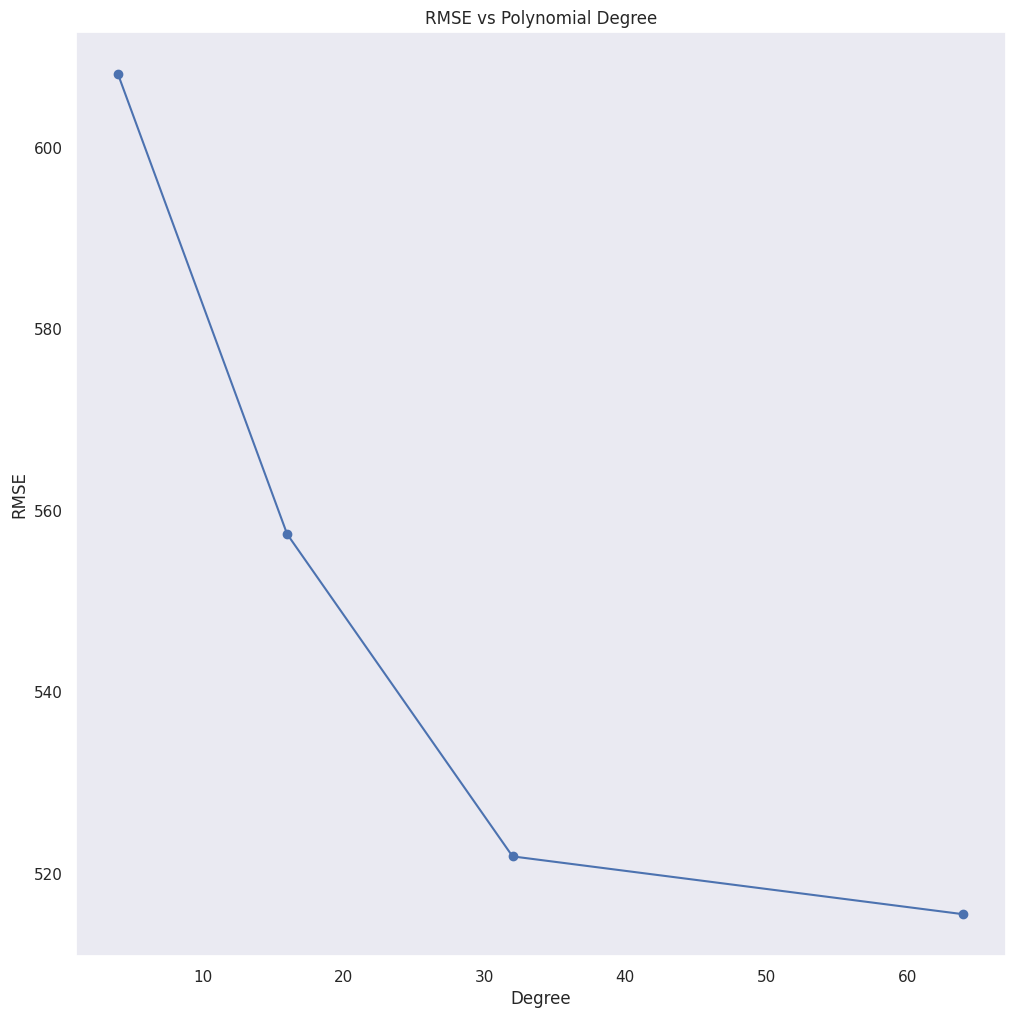

In [29]:
# Fixed dataset
n = 64
x = np.random.normal(10, 2, n)
y = x**4 + np.random.uniform(-1, 1, n)*(x**3) + np.random.uniform(0, 1, n)

degrees = [4, 16, 32, 64]

mse_list = []
rmse_list = []

for d in degrees:
    coeffs = np.polyfit(x, y, d)
    poly = np.poly1d(coeffs)

    y_pred = poly(x)

    mse = np.mean((y - y_pred)**2)
    rmse = np.sqrt(mse)

    mse_list.append(mse)
    rmse_list.append(rmse)

# 🔹 Plot MSE
plt.figure()
plt.plot(degrees, mse_list, marker='o')
plt.title("MSE vs Polynomial Degree")
plt.xlabel("Degree")
plt.ylabel("MSE")
plt.grid()
plt.show()

# 🔹 Plot RMSE
plt.figure()
plt.plot(degrees, rmse_list, marker='o')
plt.title("RMSE vs Polynomial Degree")
plt.xlabel("Degree")
plt.ylabel("RMSE")
plt.grid()
plt.show()

##Visual 4: Continuous MSE Curve (64 Points)
##Smooth trend fitting explanation
##Three regions of the curve
##How to identify optimal capacity
##The "knee" in the learning curve


/tmp/ipykernel_276/129997966.py:12: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, d)
/tmp/ipykernel_276/129997966.py:12: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, d)
/tmp/ipykernel_276/129997966.py:12: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, d)
/tmp/ipykernel_276/129997966.py:12: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, d)
/tmp/ipykernel_276/129997966.py:12: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, d)
/tmp/ipykernel_276/129997966.py:12: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, d)
/tmp/ipykernel_276/129997966.py:12: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, d)
/tmp/ipykernel_276/129997966.py:12: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, d)
/tmp/ipykernel_276/129997966.py:12: RankWarning: Polyfit may be poorly conditioned
  coe

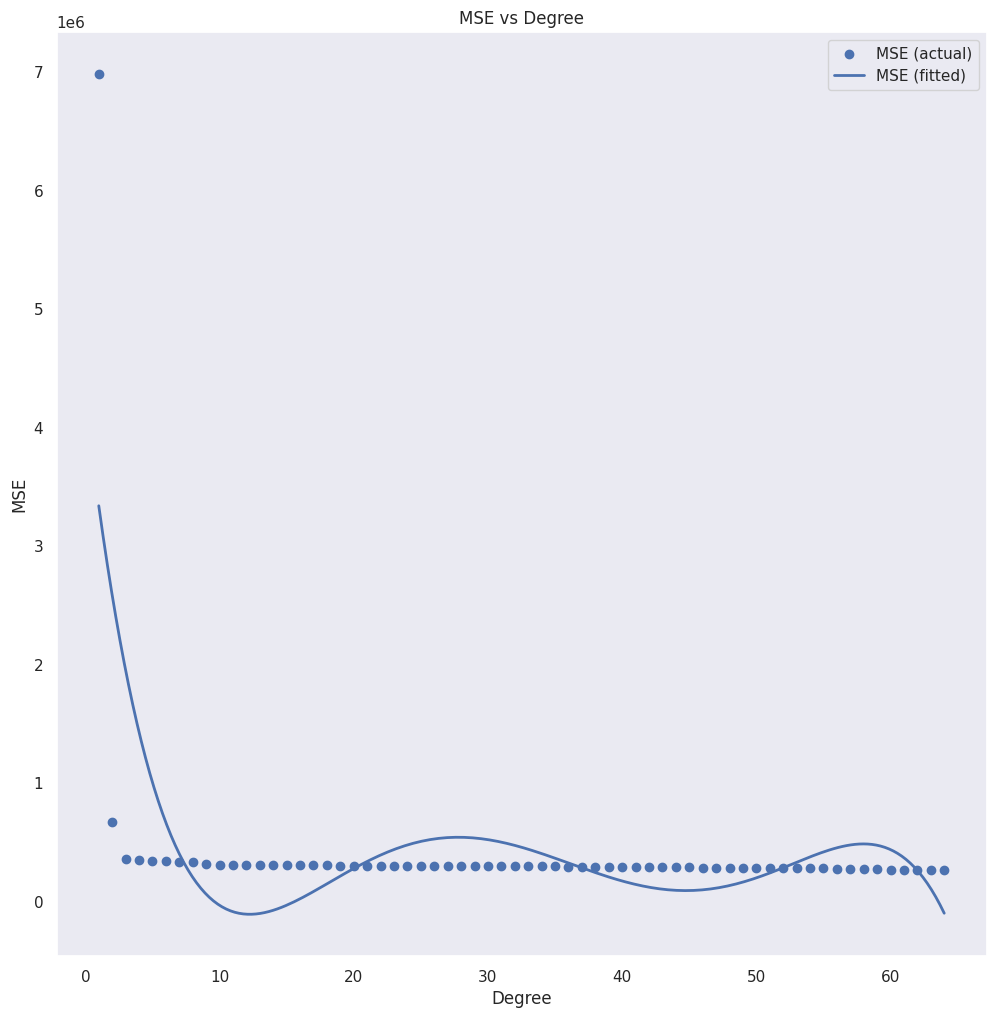

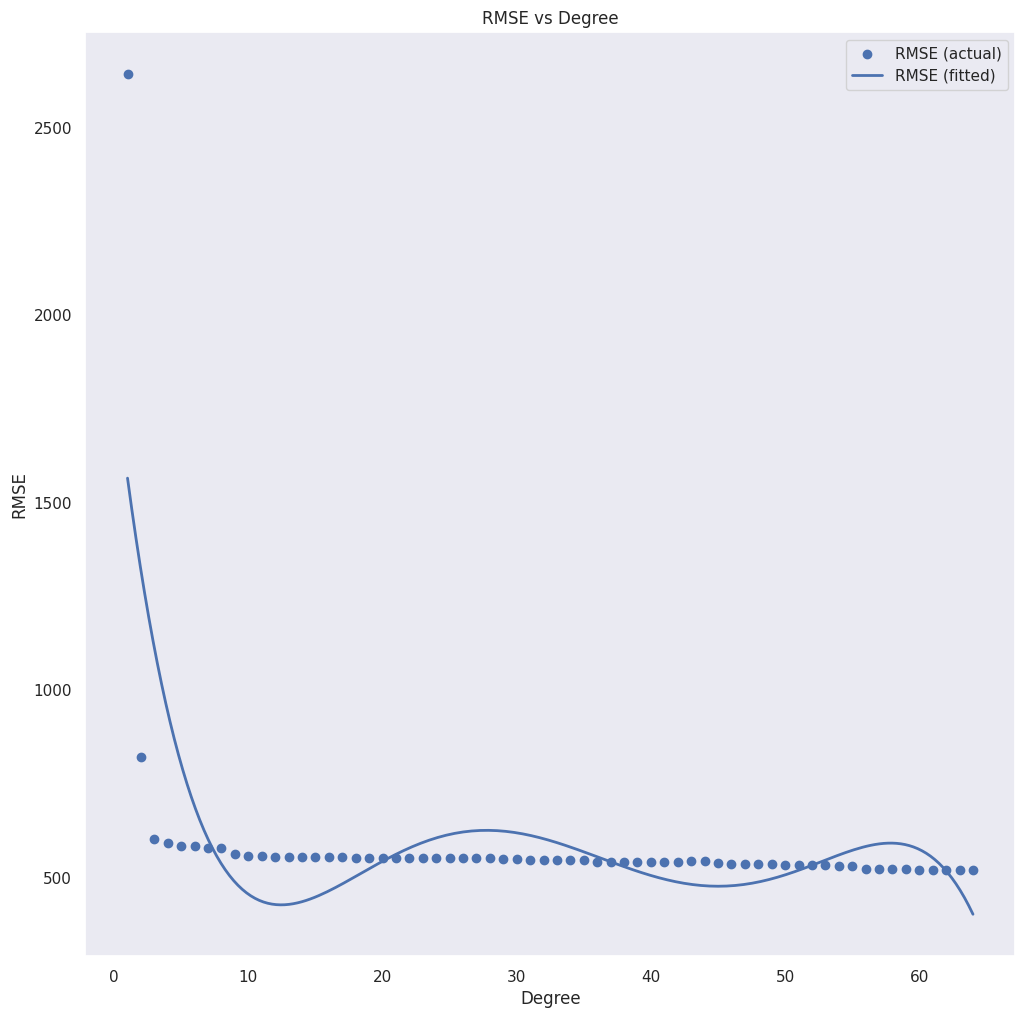

In [30]:
# Dataset
n = 64
x = np.random.normal(10, 2, n)
y = x**4 + np.random.uniform(-1, 1, n)*(x**3) + np.random.uniform(0, 1, n)

degrees = range(1, 65)

mse_list = []
rmse_list = []

for d in degrees:
    coeffs = np.polyfit(x, y, d)
    poly = np.poly1d(coeffs)

    y_pred = poly(x)

    mse = np.mean((y - y_pred)**2)
    rmse = np.sqrt(mse)

    mse_list.append(mse)
    rmse_list.append(rmse)

# 🔹 Fit smooth polynomial curve (trend line)
mse_fit = np.poly1d(np.polyfit(list(degrees), mse_list, 5))
rmse_fit = np.poly1d(np.polyfit(list(degrees), rmse_list, 5))

d_smooth = np.linspace(1, 64, 200)

# 🔹 Plot MSE
plt.figure()
plt.scatter(degrees, mse_list, label="MSE (actual)")
plt.plot(d_smooth, mse_fit(d_smooth), linewidth=2, label="MSE (fitted)")
plt.xlabel("Degree")
plt.ylabel("MSE")
plt.title("MSE vs Degree")
plt.legend()
plt.grid()
plt.show()

# 🔹 Plot RMSE
plt.figure()
plt.scatter(degrees, rmse_list, label="RMSE (actual)")
plt.plot(d_smooth, rmse_fit(d_smooth), linewidth=2, label="RMSE (fitted)")
plt.xlabel("Degree")
plt.ylabel("RMSE")
plt.title("RMSE vs Degree")
plt.legend()
plt.grid()
plt.show()

##Key Visual Lessons:
##Training loss ≠ model quality
##Smooth curves = good generalization
##The bias-variance trade-off is real
##Overfitting = memorization
##Learning curves show what you need
##Never trust training error alone
